# Disciplina: Python no ensino de Matemática


## Códigos auxiliares: Visualização de Funções de Variável Complexa.

## Sumário

- [1.Introdução](#1.-Introdução)
- [2. Paisagem Analítica](#2.-Paisagem-Analítica)
- [3. Representações no plano através de cores](#3.-Representações-no-plano-através-de-cores)
    - [3.1.1 Gráficos de fase simples](#3.1.1-Gráficos-de-fase-simples)
    - [3.1.2 Gráficos de fase aprimorado](#3.1.2-Gráficos-de-fase-aprimorado)
    - [3.2 Coloração de domínio](#3.2-Coloração-de-domínio)
- [4. Exemplos](#4.-Exemplos)
- [5. Conclusão](#5.-Conclusão)



In [52]:
# Importar PyPlot e NumPy
import matplotlib.pyplot as plt
import numpy as np
# Fonte a ser usada nas figuras geradas pela Matplotlib.
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

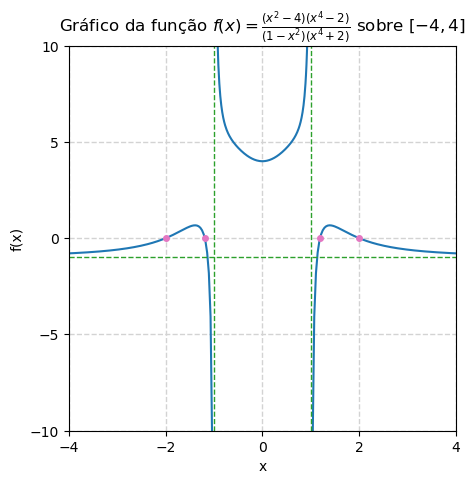

In [134]:
def f_modelo(x):
    return (x**2 - 4)*(x**4-2)/((1-x**2)*(x**4+2))

# Valores que serão plotados
x1 = np.linspace(-0.9999, 0.9999, 200)
x2 = np.linspace(1.000001, 8, 200)
#f = np.sin(2 * np.pi * x)

f1 = f_modelo(x1)
f2 = f_modelo(x2)
# Parâmetros da figura
figsize = (5, 5)
colunas = 1
linhas = 1

fig, ax = plt.subplots(linhas, colunas, figsize=figsize)
ax.plot(x1, f1, color = 'tab:blue')
ax.plot(x2, f2, color = 'tab:blue')
ax.plot(-x2, f2, color = 'tab:blue')
ax.plot([2, -2, 2**0.25, -2**0.25],[0, 0, 0, 0], 'o', ms = 4, color = 'tab:pink')
ax.plot([1,1],[-10,10], ls='--', lw = 1, color = 'tab:green')
ax.plot([-1,-1],[-10,10], ls='--', lw = 1, color = 'tab:green')
ax.plot([-4,4],[-1,-1], ls='--', lw = 1, color = 'tab:green')

ax.set(xlabel='x', ylabel='f(x)', xlim = (-4,4), ylim = (-10,10),
       title=r'Gráfico da função $f(x) = \frac{(x^2 - 4)(x^4 - 2)}{(1-x^2)(x^4+2)}$ sobre $[-4,4]$')
ax.set_xticks(np.linspace(-4,4,5))
ax.set_yticks(np.linspace(-10,10,5))
ax.grid(color='lightgray', ls='--', lw = 1)

plt.show()

In [5]:
#Importar módulos necessários
from matplotlib import cm

# Módulo com funções especiais
import scipy.special

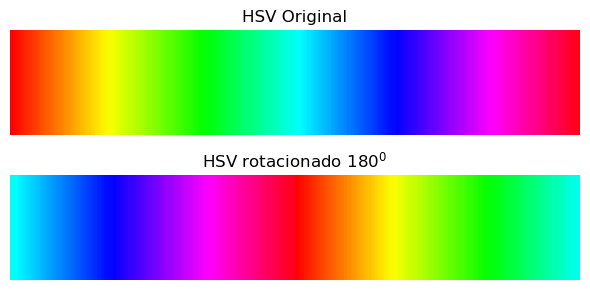

In [6]:
#Rotação do mapa de cores HSV (vermelho -> ângulo zero)
from matplotlib.colors import ListedColormap

def rotate_hsv_cmap(shift_fraction=0.25):
    """
    Creates a rotated version of the HSV colormap.
    
    Parameters:
        shift_fraction (float): Fraction to rotate by (0.0 to 1.0).
                                0.25 shifts the start color by 90 degrees.
    """
    # 1. Fetch the standard HSV colormap colors as an array (usually 256 samples)
    hsv_base = plt.colormaps['hsv']
    color_array = hsv_base(np.linspace(0, 1, 256))
    
    # 2. Calculate how many indices to shift based on the fraction
    shift_indices = int(shift_fraction * len(color_array))
    
    # 3. Cyclically shift the rows of the color array
    rotated_colors = np.roll(color_array, shift=shift_indices, axis=0)
    
    # 4. Create and return the new custom ListedColormap
    return ListedColormap(rotated_colors, name=f'rotated_hsv_{shift_fraction}')

# Generate a rotated colormap shifted by 180 degrees
rotated_hsv = rotate_hsv_cmap(shift_fraction = 0.5)

# Generate sample data to plot
data = np.linspace(0, 1, 256).reshape(1, -1)

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 3))
ax1.imshow(data, aspect='auto', cmap='hsv')
ax1.set_title('HSV Original')
ax1.axis('off')

ax2.imshow(data, aspect='auto', cmap=rotated_hsv)
ax2.set_title(r'HSV rotacionado $180^0$')
ax2.axis('off')

plt.tight_layout()
plt.show()

Calculando valores da função Gamma... Isso pode levar alguns segundos.


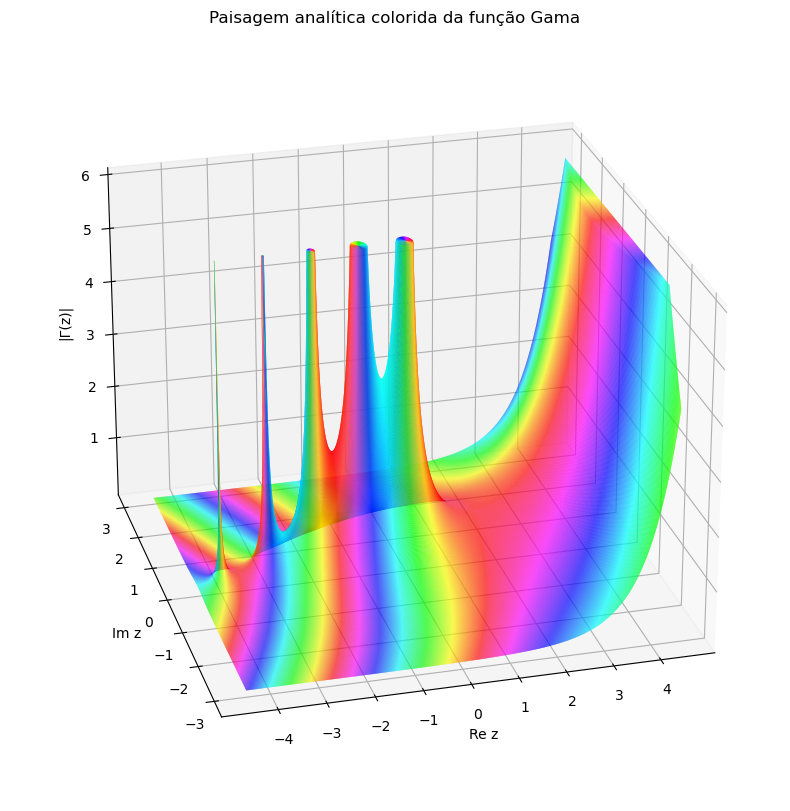

In [51]:
#Paisagem analítica colorida da função Gama.

# Criar a malha de pontos no plano complexo
# Ajuste o intervalo para focar na região mais interessante da Gamma
# (próximo a -5 a 5 no eixo real e -3 a 3 no imaginário)
x1 = np.linspace(-4.5, -0.5, 800)
x2 = np.linspace(-0.5, 4.5, 400)
y = np.linspace(-3, 3, 600)
X, Y = np.concatenate((np.meshgrid(x1, y), np.meshgrid(x2, y)), axis=2)
Z = X + 1j * Y  # Números complexos

# Calcular valores da função Gamma
print("Calculando valores da função Gamma... Isso pode levar alguns segundos.")
Gamma_vals = scipy.special.gamma(Z)

# Calcular o módulo e a fase
mod = np.abs(Gamma_vals)
phase = np.angle(Gamma_vals)  # Fase em radianos no intervalo [-pi, pi]

# Normalizar a fase para o intervalo [0, 1] para mapear para o colormap HSV
phase_normalized = (phase + np.pi) / (2 * np.pi)

# Para evitar problemas com polos (onde a função explode), limitamos o módulo
mod_limited = np.clip(mod, 0, 6)  # Ajuste o limite conforme necessário

# Criar um colormap que é verdadeiramente cíclico
import matplotlib.colors as mcolors

# Criar um colormap cíclico personalizado
class CyclicNormalize(mcolors.Normalize):
    def __call__(self, value, clip=None):
        # Mapear valores para o intervalo [0, 1] de forma cíclica
        result = np.mod(value, 1.0)
        return result

# Usar com a fase normalizada
norm = CyclicNormalize(vmin=0, vmax=1)

# Criar a figura 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plotar a superfície com a cor baseada na fase
# Usamos o colormap 'hsv' que é um círculo de cores
surf = ax.plot_surface(X, Y, mod_limited, 
                        facecolors=rotated_hsv(norm(phase_normalized)),
                        rstride=1, cstride=1, 
                        linewidth=0,           # Sem linhas de contorno
                        antialiased=True,      # Suavização
                        shade=False,           # Sem sombreamento automático
                        alpha=1.0)             # <-- ALPHA = 1.0 (totalmente opaco)


# Ajustar os ângulos de visão para uma boa perspectiva (similar à da figura)
ax.view_init(elev=25, azim = -105)

#grid
ax.set(xticks=np.arange(-4,5),
       yticks=np.arange(-3,4),
       zticks=np.arange(1,7))

# Rótulos e título
ax.set_xlabel('Re z')
ax.set_ylabel('Im z')
ax.zaxis.set_rotate_label(False)  # disable automatic rotation
ax.set_zlabel('|Γ(z)|', rotation=90)
ax.set_title('Paisagem analítica colorida da função Gama', fontsize=12)



plt.show()

Calculando valores da função Gamma...


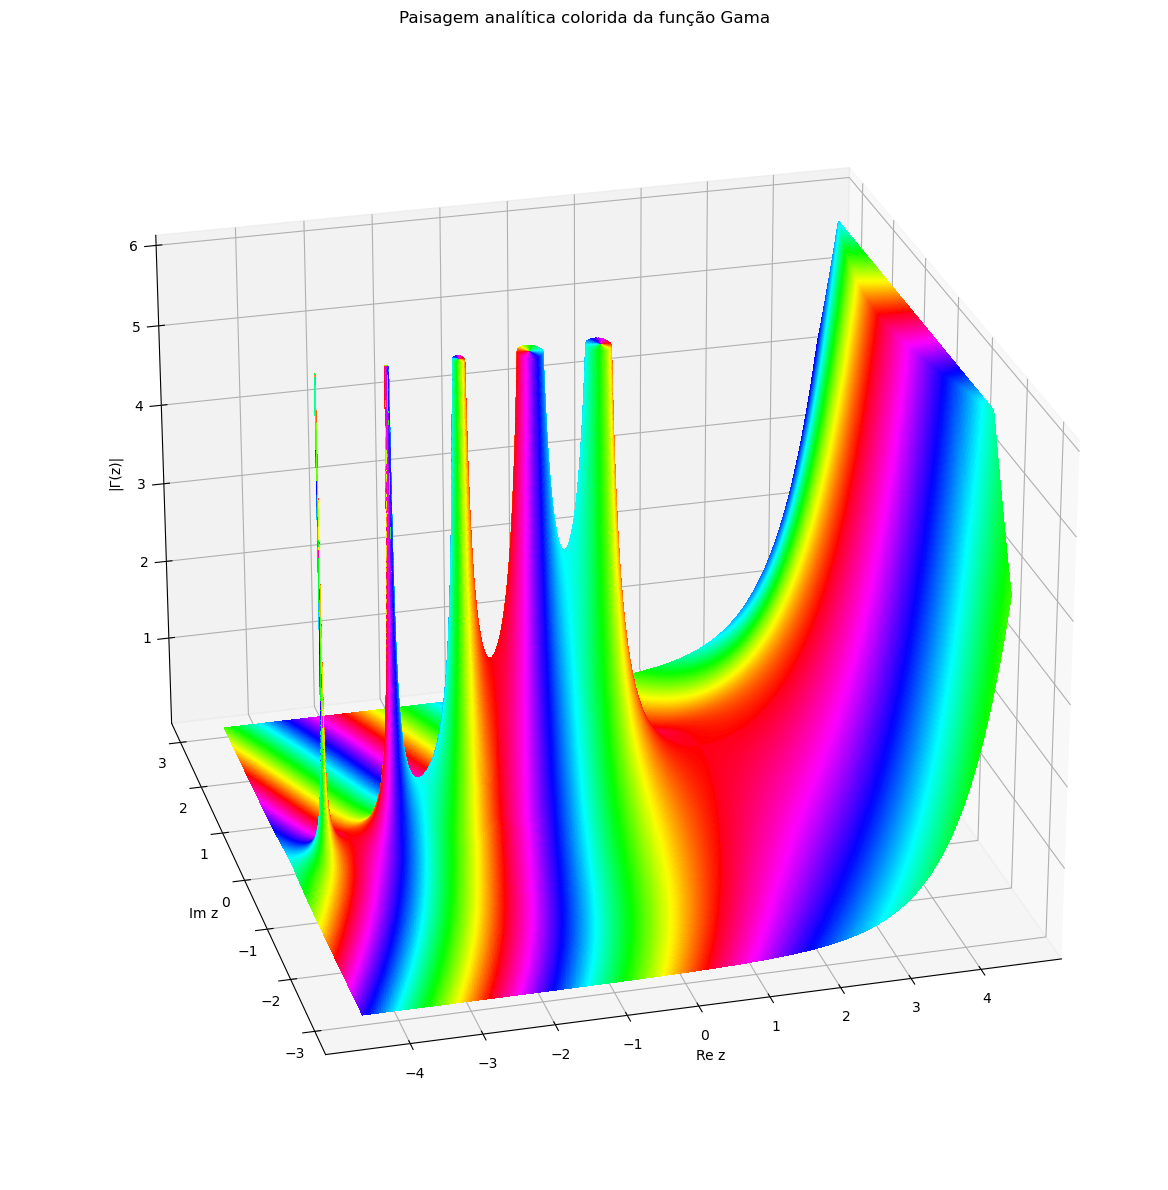

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import scipy.special
from mpl_toolkits.mplot3d import Axes3D

def rotate_hsv_cmap(shift_fraction=0.25):
    hsv_base = plt.colormaps['hsv']
    color_array = hsv_base(np.linspace(0, 1, 256))
    shift_indices = int(shift_fraction * len(color_array))
    rotated_colors = np.roll(color_array, shift=shift_indices, axis=0)
    return ListedColormap(rotated_colors, name=f'rotated_hsv_{shift_fraction}')

class CyclicNormalize(Normalize):
    def __call__(self, value, clip=None):
        result = np.mod(value, 1.0)
        result = np.ma.masked_invalid(result)
        return result

rotated_hsv = rotate_hsv_cmap(shift_fraction=0.5)

# Resolução mais alta sem zoom
x1 = np.linspace(-4.5, -2.5, 1000)
x2 = np.linspace(-2.5, -0.5, 800)
x3 = np.linspace(-0.5, 4.5, 600)
y = np.linspace(-3, 3, 1000)

X1, Y1 = np.meshgrid(x1, y)
X2, Y2 = np.meshgrid(x2, y)
X3, Y3 = np.meshgrid(x3, y)

X = np.concatenate([X1, X2, X3], axis=1)
Y = np.concatenate([Y1, Y2, Y3], axis=1)
Z_complex = X + 1j * Y

print("Calculando valores da função Gamma...")
Gamma_vals = scipy.special.gamma(Z_complex)

mod = np.abs(Gamma_vals)
phase = np.angle(Gamma_vals)
phase_normalized = (phase + np.pi) / (2 * np.pi)
mod_limited = np.clip(mod, 0, 6)

fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

cyclic_norm = CyclicNormalize(vmin=0, vmax=1)
phase_cyclic = cyclic_norm(phase_normalized)

colors = rotated_hsv(phase_cyclic)
colors[..., 3] = 1.0  # Alpha = 1 explicitamente

surf = ax.plot_surface(X, Y, mod_limited, 
                        facecolors=colors,
                        rstride=1, cstride=1, 
                        linewidth=0,
                        antialiased=False,
                        shade=False,
                        alpha=1.0)

ax.view_init(elev=25, azim=-105)
ax.set(xticks=np.arange(-4, 5),
       yticks=np.arange(-3, 4),
       zticks=np.arange(1, 7))

ax.set_xlabel('Re z')
ax.set_ylabel('Im z')
ax.zaxis.set_rotate_label(False)
ax.set_zlabel('|Γ(z)|', rotation=90)
ax.set_title('Paisagem analítica colorida da função Gama', fontsize=12)

plt.tight_layout()
plt.show()

In [135]:
#Exemplos de gráficos de fase aprimorados
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# ============================================
# PALETAS DE CORES - USANDO np.ceil DIRETAMENTE
# ============================================

def rotated_hsv_plain(z, hue_shift=0.5, **kwargs):
    """Coluna 1: Plain phase plot (fase pura, sem curvas)"""
    arg = np.angle(z)
    hue = ((arg + np.pi) / (2 * np.pi) + hue_shift) % 1.0
    saturation = np.ones_like(hue)
    value = np.ones_like(hue)
    return hue, saturation, value


def rotated_hsv_modulus_sawtooth(z, n_modulus_lines=8, min_brightness=0.45, 
                                  max_brightness=0.95, hue_shift=0.5, **kwargs):
    """
    Coluna 2: Sawtooth aplicado ao MÓDULO.
    g(x) = ceil(x) - x  (sawtooth decrescente)
    """
    arg = np.angle(z)
    hue = ((arg + np.pi) / (2 * np.pi) + hue_shift) % 1.0
    saturation = np.ones_like(hue)
    
    # Sawtooth do módulo: ceil(log|f| * n_lines) - log|f| * n_lines
    modulus = np.abs(z)
    log_mod = np.log(modulus + 1e-10)
    log_max = np.max(log_mod)
    scaled = n_modulus_lines * log_mod/log_max
    sawtooth = np.ceil(scaled) - scaled  # <-- usando ceil diretamente
    
    # Compressão para suavizar o contraste
    contrast = 0.6
    sawtooth_compressed = sawtooth ** contrast
    
    value = min_brightness + (max_brightness - min_brightness) * sawtooth_compressed
    value = np.clip(value, min_brightness, max_brightness)
    
    return hue, saturation, value


def rotated_hsv_phase_sawtooth(z, n_phase_lines=12, min_brightness=0.45, 
                                max_brightness=0.95, hue_shift=0.5, **kwargs):
    """
    Coluna 3: Sawtooth aplicado à FASE (isochromatic lines)
    """
    arg = np.angle(z)
    arg_norm = (arg + np.pi) / (2 * np.pi)
    
    hue = (arg_norm + hue_shift) % 1.0
    saturation = np.ones_like(hue)
    
    # Sawtooth da fase: ceil(n*arg/2π) - n*arg/2π
    x = n_phase_lines * arg_norm
    sawtooth = np.ceil(x) - x  # <-- usando ceil diretamente
    
    contrast = 0.6
    sawtooth_compressed = sawtooth ** contrast
    
    value = min_brightness + (max_brightness - min_brightness) * sawtooth_compressed
    value = np.clip(value, min_brightness, max_brightness)
    
    return hue, saturation, value


def rotated_hsv_modulus_phase_sawtooth(z, n_modulus_lines=8, n_phase_lines=12, 
                                        min_brightness=0.45, max_brightness=0.95,
                                        hue_shift=0.5, **kwargs):
    """
    Coluna 4: Sawtooth no MÓDULO E na FASE → polar tiling
    """
    arg = np.angle(z)
    arg_norm = (arg + np.pi) / (2 * np.pi)
    
    # Fase discretizada para criar linhas radiais
    phase_discrete = np.floor(arg_norm * n_phase_lines) / n_phase_lines
    hue = (phase_discrete + hue_shift) % 1.0
    saturation = np.ones_like(hue)
    
    # Sawtooth do módulo
    modulus = np.abs(z)
    log_mod = np.log(modulus + 1e-10)
    log_max = np.max(log_mod)
    scaled_mod = n_modulus_lines * log_mod/log_max
    sawtooth_mod = np.ceil(scaled_mod) - scaled_mod  # <-- usando ceil
    
    # Sawtooth da fase
    x_phase = n_phase_lines * arg_norm
    sawtooth_phase = np.ceil(x_phase) - x_phase  # <-- usando ceil
    
    # Combinar os dois sawtooths (multiplicação cria o grid)
    sawtooth_combined = sawtooth_mod * sawtooth_phase
    
    contrast = 0.6
    sawtooth_compressed = sawtooth_combined ** contrast
    
    value = min_brightness + (max_brightness - min_brightness) * sawtooth_compressed
    value = np.clip(value, min_brightness, max_brightness)
    
    return hue, saturation, value


def rotated_hsv_brightness(z, min_brightness=0.15, max_brightness=0.95, 
                           hue_shift=0.5, **kwargs):
    """
    Coluna 5: Standard domain coloring com brilho variável (suave)
    """
    arg = np.angle(z)
    hue = ((arg + np.pi) / (2 * np.pi) + hue_shift) % 1.0
    saturation = np.ones_like(hue)
    
    modulus = np.abs(z)
    log_mod = np.log(modulus + 1e-10)
    log_mod_norm = (log_mod - log_mod.min()) / (log_mod.max() - log_mod.min() + 1e-10)
    value = min_brightness + (max_brightness - min_brightness) * log_mod_norm
    value = np.clip(value, min_brightness, max_brightness)
    
    return hue, saturation, value


In [136]:
# ============================================
# FUNÇÃO PRINCIPAL
# ============================================

def plot_phase_portrait(ax, func, x_range=(-3, 3), y_range=(-3, 3),
                        palette='plain',
                        hue_shift=0.5,
                        **palette_kwargs):
    """Plota o phase portrait com a paleta especificada."""
    
    x = np.linspace(x_range[0], x_range[1], 600)
    y = np.linspace(y_range[0], y_range[1], 600)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    
    with np.errstate(divide='ignore', invalid='ignore'):
        f_vals = func(Z)
        f_vals = np.nan_to_num(f_vals, nan=0.0, posinf=0.0, neginf=0.0)
    
    palettes = {
        'plain': rotated_hsv_plain,
        'modulus_sawtooth': rotated_hsv_modulus_sawtooth,
        'phase_sawtooth': rotated_hsv_phase_sawtooth,
        'modulus_phase_sawtooth': rotated_hsv_modulus_phase_sawtooth,
        'brightness': rotated_hsv_brightness
    }
    
    palette_func = palettes[palette]
    hue, saturation, value = palette_func(f_vals, hue_shift=hue_shift, **palette_kwargs)
    
    hsv_stack = np.stack([hue, saturation, value], axis=-1)
    colors = hsv_to_rgb(hsv_stack)
    colors = np.dstack([colors, np.ones_like(hue)])
    
    ax.imshow(colors, extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
              origin='lower', aspect='equal')
    #ax.set_xlabel('Re z', fontsize=10)
    #ax.set_ylabel('Im z', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.2)
    
    return colors


In [137]:
# ============================================
# FUNÇÃO PARA CRIAR OS 10 PLOTS (2x5)
# COM DIMENSÕES DIFERENTES POR LINHA
# ============================================

def create_wegert_style_plots(func, func_name="f(z)", 
                              x_range_top=(-2, 2), y_range_top=(-2, 2),
                              x_range_bottom=(-2, 2), y_range_bottom=(-2, 2),
                              figsize=(18, 10),
                              n_modulus_lines=10,
                              n_phase_lines=12):
    """
    Cria 10 plots no estilo Wegert: 5 colunas x 2 linhas.
    
    Parâmetros:
    - x_range_top, y_range_top: domínio para a linha 1 (f(z)=z)
    - x_range_bottom, y_range_bottom: domínio para a linha 2 (função fornecida)
    - n_modulus_lines: número de curvas de nível do módulo
    - n_phase_lines: número de curvas de nível da fase
    """
    
    palette_configs = [
        ('plain', 'Plain Phase Plot', {}),
        ('modulus_sawtooth', 'Módulo (sawtooth)', 
         {'n_modulus_lines': n_modulus_lines, 
          'min_brightness': 0.45, 'max_brightness': 0.95}),
        ('phase_sawtooth', 'Fase discretizada', 
         {'n_phase_lines': n_phase_lines, 
          'min_brightness': 0.45, 'max_brightness': 0.95}),
        ('modulus_phase_sawtooth', 'Módulo + Fase (polar tiling)', 
         {'n_modulus_lines': n_modulus_lines,
          'n_phase_lines': n_phase_lines,
          'min_brightness': 0.45, 'max_brightness': 0.95}),
        ('brightness', 'Brilho variável', {'min_brightness': 0.15, 'max_brightness': 0.95})
    ]
    
    # Linha 1: f(z) = z, Linha 2: função fornecida
    funcs = [
        ('f(z) = z', lambda z: z, x_range_top, y_range_top),
        (func_name, func, x_range_bottom, y_range_bottom)
    ]
    
    fig, axes = plt.subplots(2, 5, figsize=figsize)
    
    for i, (f_label, f, x_range, y_range) in enumerate(funcs):
        for j, (palette, title, kwargs) in enumerate(palette_configs):
            ax = axes[i, j]
            
            ax.tick_params(axis="both", length=0, labelbottom=False, labelleft=False)
            
            plot_phase_portrait(
                ax, f, x_range, y_range,
                palette=palette,
                **kwargs
            )
            
            #if i == 0:
            #    ax.set_title(title, fontsize=12)
            #if j == 0:
            #    ax.set_ylabel(f_label, fontsize=12, rotation=0, labelpad=30)
    
    plt.tight_layout()
    return fig


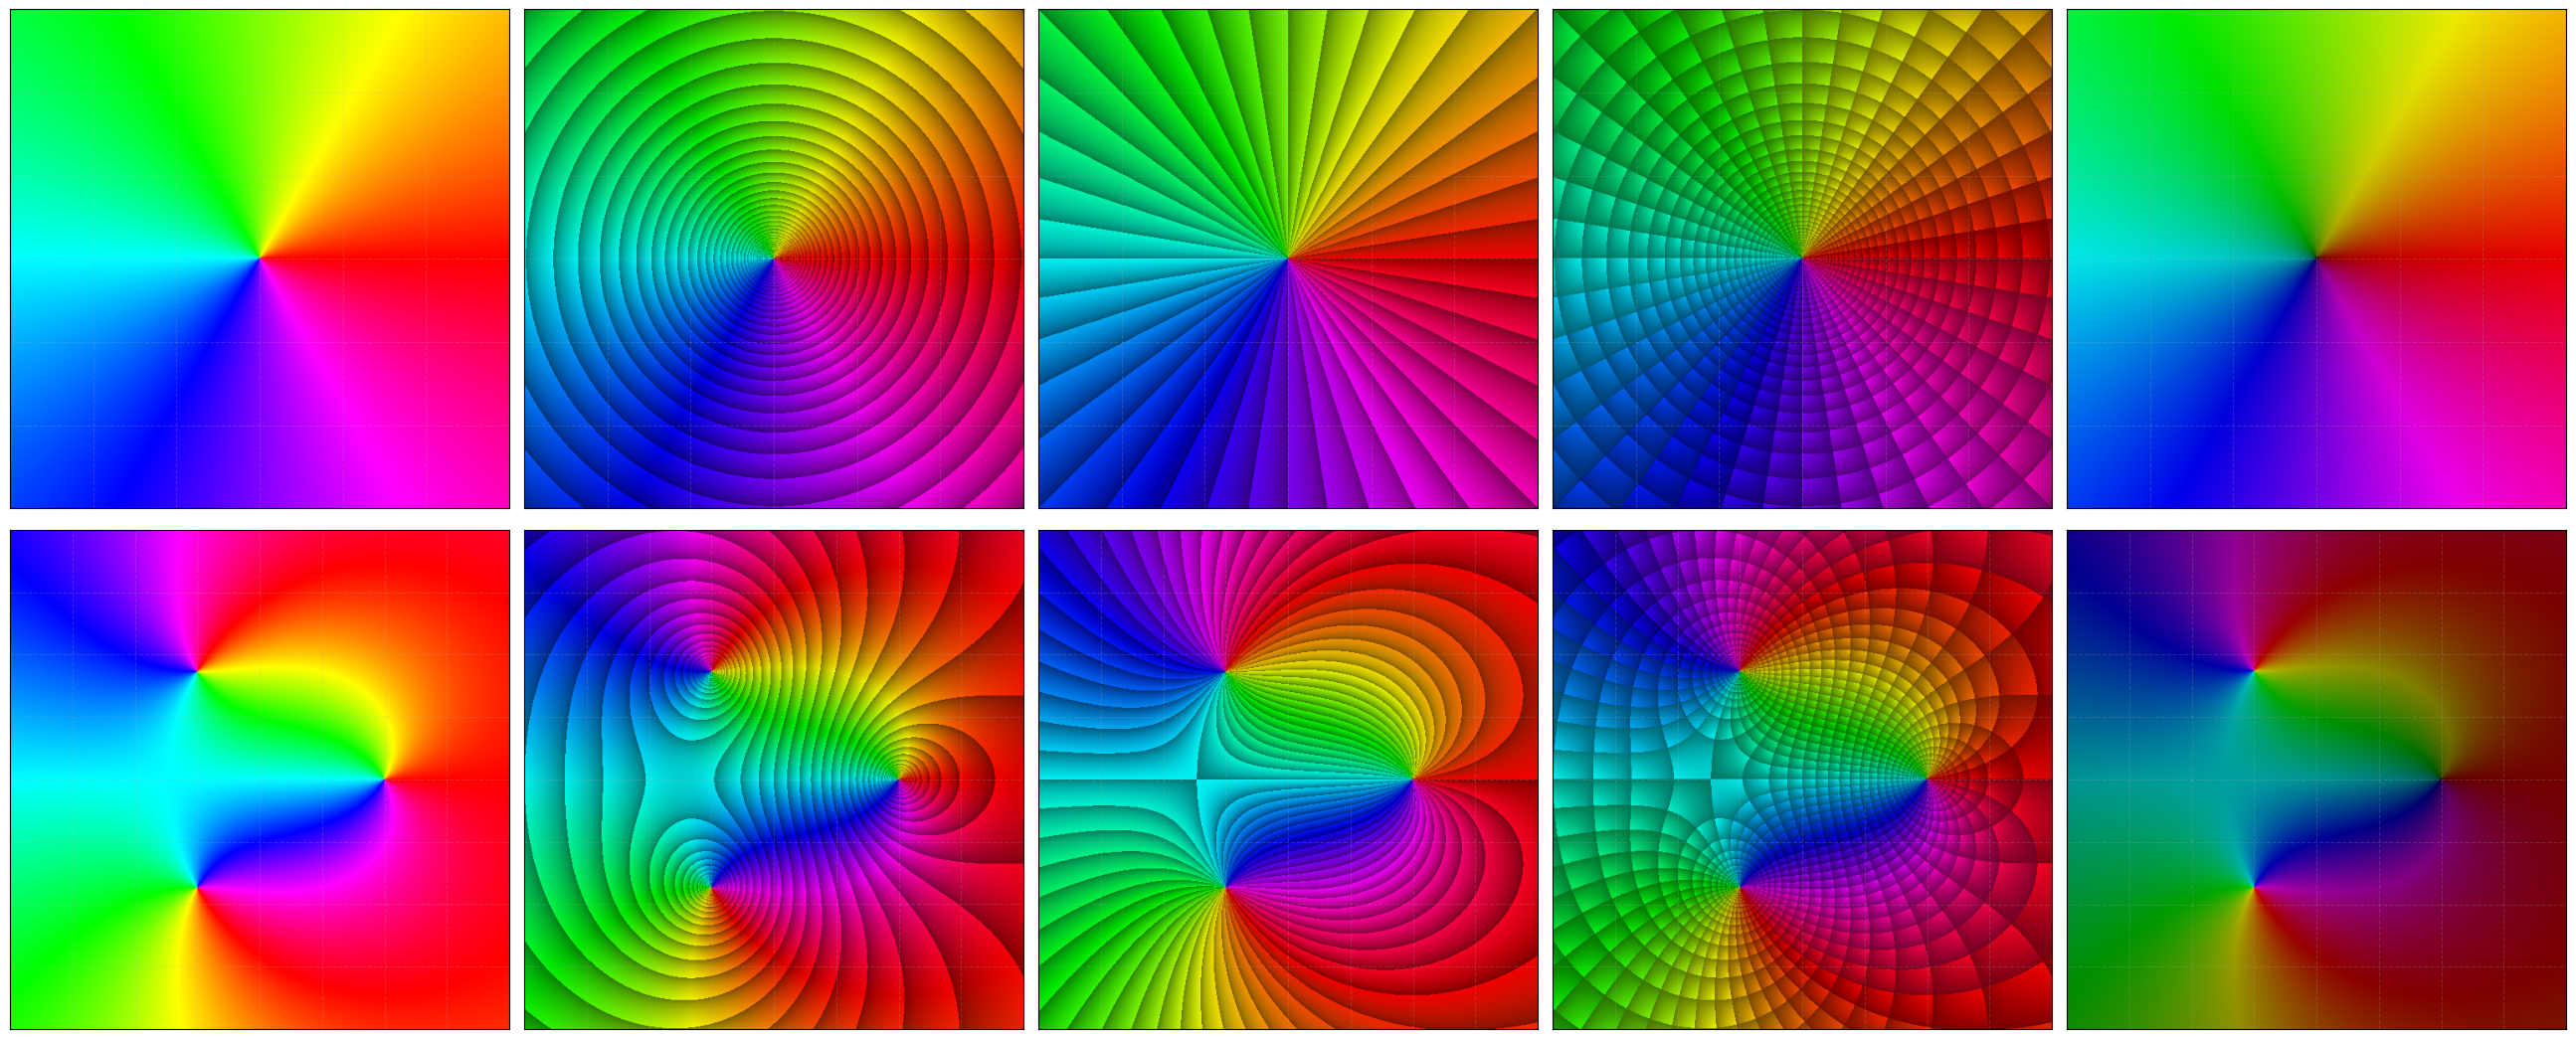

In [143]:
# ============================================
# EXEMPLO DE USO
# ============================================

def f(z):
    return (z - 1) / (z**2 + z + 1)

# Criar os plots com dimensões diferentes para cada linha
fig = create_wegert_style_plots(
    func=f,
    func_name="f(z) = (z-1)/(z²+z+1)",
    # Linha 1: f(z)=z → domínio menor para ver os detalhes
    x_range_top=(-15, 15),
    y_range_top=(-15, 15),
    # Linha 2: função personalizada → domínio maior
    x_range_bottom=(-2, 2),
    y_range_bottom=(-2, 2),
    figsize=(26, 11),
    n_modulus_lines=26,
    n_phase_lines=40
)

plt.show()